In [2]:
import pandas as pd

In [4]:
hn = pd.read_csv(r"C:\Users\ASUS\Desktop\model\h1n1_vaccine_prediction (1).csv")

In [5]:
hn.head()

,unique_id,h1n1_worry,h1n1_awareness,antiviral_medication,contact_avoidance,bought_face_mask,wash_hands_frequently,avoid_large_gatherings,reduced_outside_home_cont,avoid_touch_face,...,race,sex,income_level,marital_status,housing_status,employment,census_msa,no_of_adults,no_of_children,h1n1_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,Non-MSA,0.0,0.0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,White,Male,Below Poverty,Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",2.0,0.0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Principle City",0.0,0.0,0
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,0.0,0


In [6]:
hn=hn.drop(['unique_id'],axis=1)

In [7]:
hn.isnull().sum()[hn.isnull().sum()>0]

h1n1_worry                      92
h1n1_awareness                 116
antiviral_medication            71
contact_avoidance              208
bought_face_mask                19
wash_hands_frequently           42
avoid_large_gatherings          87
reduced_outside_home_cont       82
avoid_touch_face               128
dr_recc_h1n1_vacc             2160
dr_recc_seasonal_vacc         2160
chronic_medic_condition        971
cont_child_undr_6_mnths        820
is_health_worker               804
has_health_insur             12274
is_h1n1_vacc_effective         391
is_h1n1_risky                  388
sick_from_h1n1_vacc            395
is_seas_vacc_effective         462
is_seas_risky                  514
sick_from_seas_vacc            537
qualification                 1407
income_level                  4423
marital_status                1408
housing_status                2042
employment                    1463
no_of_adults                   249
no_of_children                 249
dtype: int64

In [8]:
hn[hn.select_dtypes(include='number').columns]=hn.select_dtypes(include='number').fillna(hn.select_dtypes(include='number').median())

In [9]:
hn.qualification=hn.qualification.fillna('College Graduate')
hn.income_level =hn.income_level .fillna('<= $75,000, Above Poverty')
hn.marital_status =hn.marital_status.fillna('Married')
hn.housing_status =hn.housing_status.fillna('Own')
hn.employment =hn.employment .fillna('Employed')

In [10]:
hn['age_bracket'].value_counts()

age_bracket
65+ Years        6843
55 - 64 Years    5563
45 - 54 Years    5238
18 - 34 Years    5215
35 - 44 Years    3848
Name: count, dtype: int64

In [11]:
hn['qualification'].value_counts()

qualification
College Graduate    11504
Some College         7043
12 Years             5797
< 12 Years           2363
Name: count, dtype: int64

In [12]:
hn.select_dtypes(include='object').columns

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5660\244710052.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  hn.select_dtypes(include='object').columns


Index(['age_bracket', 'qualification', 'race', 'sex', 'income_level',
       'marital_status', 'housing_status', 'employment', 'census_msa'],
      dtype='str')

In [13]:
hn.income_level=hn.income_level.replace({'Below Poverty':0,'> $75,000':1,'<= $75,000, Above Poverty':2})
hn.qualification=hn.qualification.replace({'< 12 Years':0,'12 Years':1,'Some College':2,'College Graduate':3})
hn.census_msa=hn.census_msa.replace({'MSA, Not Principle  City':0,'MSA, Principle City':1,'Non-MSA':2})

In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [15]:
hn['age_bracket']=le.fit_transform(hn['age_bracket'])
hn['race']=le.fit_transform(hn['race'])
hn['sex']=le.fit_transform(hn['sex'])
hn['marital_status']=le.fit_transform(hn['marital_status'])
hn['housing_status']=le.fit_transform(hn['housing_status'])
hn['employment']=le.fit_transform(hn['employment'])



In [16]:
from sklearn.model_selection import train_test_split
hn_train,hn_test=train_test_split(hn,test_size=.2,random_state=132)

In [17]:
df0= hn_train[hn_train.h1n1_vaccine==1]
hn_train=pd.concat([hn_train,df0])

hn_train_x=hn_train.iloc[:,0:-1]
hn_train_y=hn_train.iloc[:,-1]


In [18]:
hn_test_x=hn_test.iloc[:,0:-1]
hn_test_y=hn_test.iloc[:,-1]

In [19]:
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression()
lr.fit(hn_train_x,hn_train_y)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [20]:
pred= lr.predict(hn_test_x)

In [21]:
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,f1_score,precision_score,roc_auc_score,roc_curve

In [22]:
confusion_matrix(hn_test_y,pred)

array([[3763,  471],
       [ 456,  652]])

In [23]:
Acc= accuracy_score(hn_test_y,pred)*100

In [24]:
recall= recall_score(hn_test_y,pred)*100

In [25]:
f1=f1_score(hn_test_y,pred)*100

In [26]:
precision= precision_score(hn_test_y,pred)*100

In [27]:
roc_score= roc_auc_score(hn_test_y,pred)*100

In [28]:
FPR=471*100/(3763+471)

In [29]:
print("Accuracy : ", Acc,"\n","recall : ",recall,"\n","f1_score : ",f1,"\n","precision : ",precision,"\n","roc_score : ",roc_score,"\n","FPR : ",FPR)

Accuracy :  82.64694870834893 
 recall :  58.844765342960294 
 f1_score :  58.44912595248767 
 precision :  58.05877114870882 
 roc_score :  73.86026646930726 
 FPR :  11.124232404345772


In [30]:
pred_prob= lr.predict_proba(hn_test_x)
# pred_prob[:,-1]


In [31]:
fpr,tpr,the= roc_curve(hn_test_y,pred_prob[:,-1])

Text(0, 0.5, 'TPR')

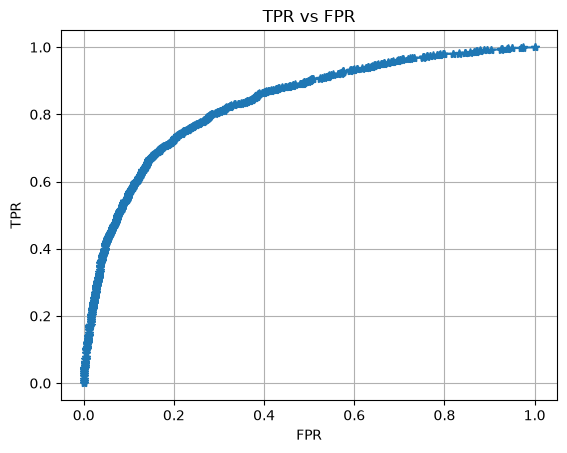

In [32]:
import matplotlib.pyplot as plt
plt.plot(fpr,tpr,marker='*')
plt.grid()
plt.title(" TPR vs FPR ")
plt.xlabel("FPR")
plt.ylabel("TPR")

In [33]:
import joblib

joblib.dump(lr, "h1n1_logistic_regression.pkl")

['h1n1_logistic_regression.pkl']

In [34]:
# pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
